In [14]:
# URL raw de la imagen
url = "https://raw.githubusercontent.com/mvera1412/tallerPS/main/data/goku_vs_piccolo.jpeg"

# Crear carpeta solo si no existe (silencioso)
!mkdir -p data

# Descargar (sobrescribe si ya existe)
!wget -q -O data/goku_vs_piccolo.jpeg "$url"

In [15]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

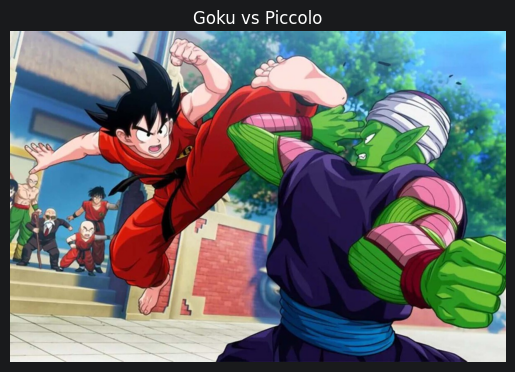

In [16]:

img = mpimg.imread("data/goku_vs_piccolo.jpeg")

plt.imshow(img)
plt.axis("off")
plt.title("Goku vs Piccolo")
plt.show()

In [17]:
# Dimensiones originales
shape_original = img.shape  # (alto, ancho, canales)
alto, ancho, canales = shape_original

print(f"Dimensiones originales: {shape_original}")
X = img.reshape(-1, canales)

print(f"Shape para K-means: {X.shape}")

Dimensiones originales: (800, 1200, 3)
Shape para K-means: (960000, 3)


**K-Means**

Se desea utilizar un algoritmo de k-means, primero para comprimir una imagen reduciendo la cantidad de colores a 16 y luego para separar 3 tendencias distintas en el consumo diario de distintas personas. Para esto, primero una breve explicacion del algoritmo:

Se parte de un conjunto de datos $X = \{x_1, x_2, \dots, x_N\}$ con $x_i \in \mathbb{R}^d$.

Se definen los centroides iniciales, en nuestro caso como una selección aleatoria entre datos del conjunto.

Cada punto se asigna al centroide más cercano:

$$
c_i = \arg\min_{j \in \{1,\dots,k\}} \|x_i - \mu_j\|^2
$$

Luego los centroides se recalculan como el promedio de los puntos asignados:

$$
\mu_j = \frac{1}{|C_j|} \sum_{x_i \in C_j} x_i
$$

Estos pasos se repiten hasta que el cambio en los centroides sea menor a un umbral (o llegar a un numero máximo de iteraciones).


Parámetros del modelo:

$$
k: \text{ número de clusters}
$$

$$
\mu_j^{(0)}: \text{ inicialización de los centroides}
$$

$$
\varepsilon: \text{ tolerancia para la convergencia}
$$

$$
\text{max\_iter}: \text{ número máximo de iteraciones}
$$

Además se agrega un parámetro random_state, que permite repetitibilidad ya que asigna una semilla para el rng del selector aleatorio de los centroides iniciales.

In [18]:
class KMeans:
    def __init__(self, k=8, max_iter=100, tol=1e-4, random_state=None):
        self.k = k
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.cluster_centers_ = None

    def fit(self, X):
        rng = np.random.default_rng(self.random_state)

        # Inicialización de centroides (elegidos de los datos)
        indices = rng.choice(X.shape[0], self.k, replace=False)
        self.cluster_centers_ = X[indices]

        for iteration in range(self.max_iter):
            # Paso 1: asignación
            distances = np.linalg.norm(
                X[:, None, :] - self.cluster_centers_[None, :, :],
                axis=2
            )
            labels = np.argmin(distances, axis=1)

            # Paso 2: actualización
            new_centers = np.array([
                X[labels == j].mean(axis=0) if np.any(labels == j)
                else self.cluster_centers_[j]  # evita clusters vacíos
                for j in range(self.k)
            ])

            # Paso 3: condición de corte
            shift = np.linalg.norm(new_centers - self.cluster_centers_)
            if shift < self.tol:
                print(f"Se llegó a la convergencia en {iteration} iteracioness")
                break

            self.cluster_centers_ = new_centers

        return self

    def predict(self, X):
        distances = np.linalg.norm(
            X[:, None, :] - self.cluster_centers_[None, :, :],
            axis=2
        )
        return np.argmin(distances, axis=1)

    def fit_predict(self, X):
        self.fit(X)
        return self.predict(X)

In [6]:
kmeans = KMeans(k=16, random_state=42)
kmeans.fit(X)

print("Centroides (diccionario de colores):")
print(kmeans.cluster_centers_)

Se llegó a la convergencia en 76 iteracioness
Centroides (diccionario de colores):
[[105.97803402 192.92827948 243.46957415]
 [ 23.22523699   9.91171879  20.32810637]
 [237.01218636 227.77465326 222.61252749]
 [ 57.12057721 122.56828562 153.93781877]
 [ 33.21070642  88.52249254 106.99112486]
 [ 63.99152173  54.07353177  78.22760707]
 [211.45509612 201.98964548 186.24998286]
 [118.52194264  99.35551538 114.47840408]
 [ 25.81442878 102.89755193  23.78909496]
 [108.52872374 188.20047037  69.45211665]
 [147.565222    23.10724453  23.63478065]
 [177.51674272 168.92143208 148.57280449]
 [ 51.1566666  143.00802319  51.87597738]
 [ 27.84314962  24.7143268   64.70449392]
 [219.05836128 123.16637075 130.4061452 ]
 [ 83.48593649 155.91522925 179.1227761 ]]


Se llegó a la convergencia en 53 iteracioness
Se llegó a la convergencia en 76 iteracioness
Se llegó a la convergencia en 86 iteracioness


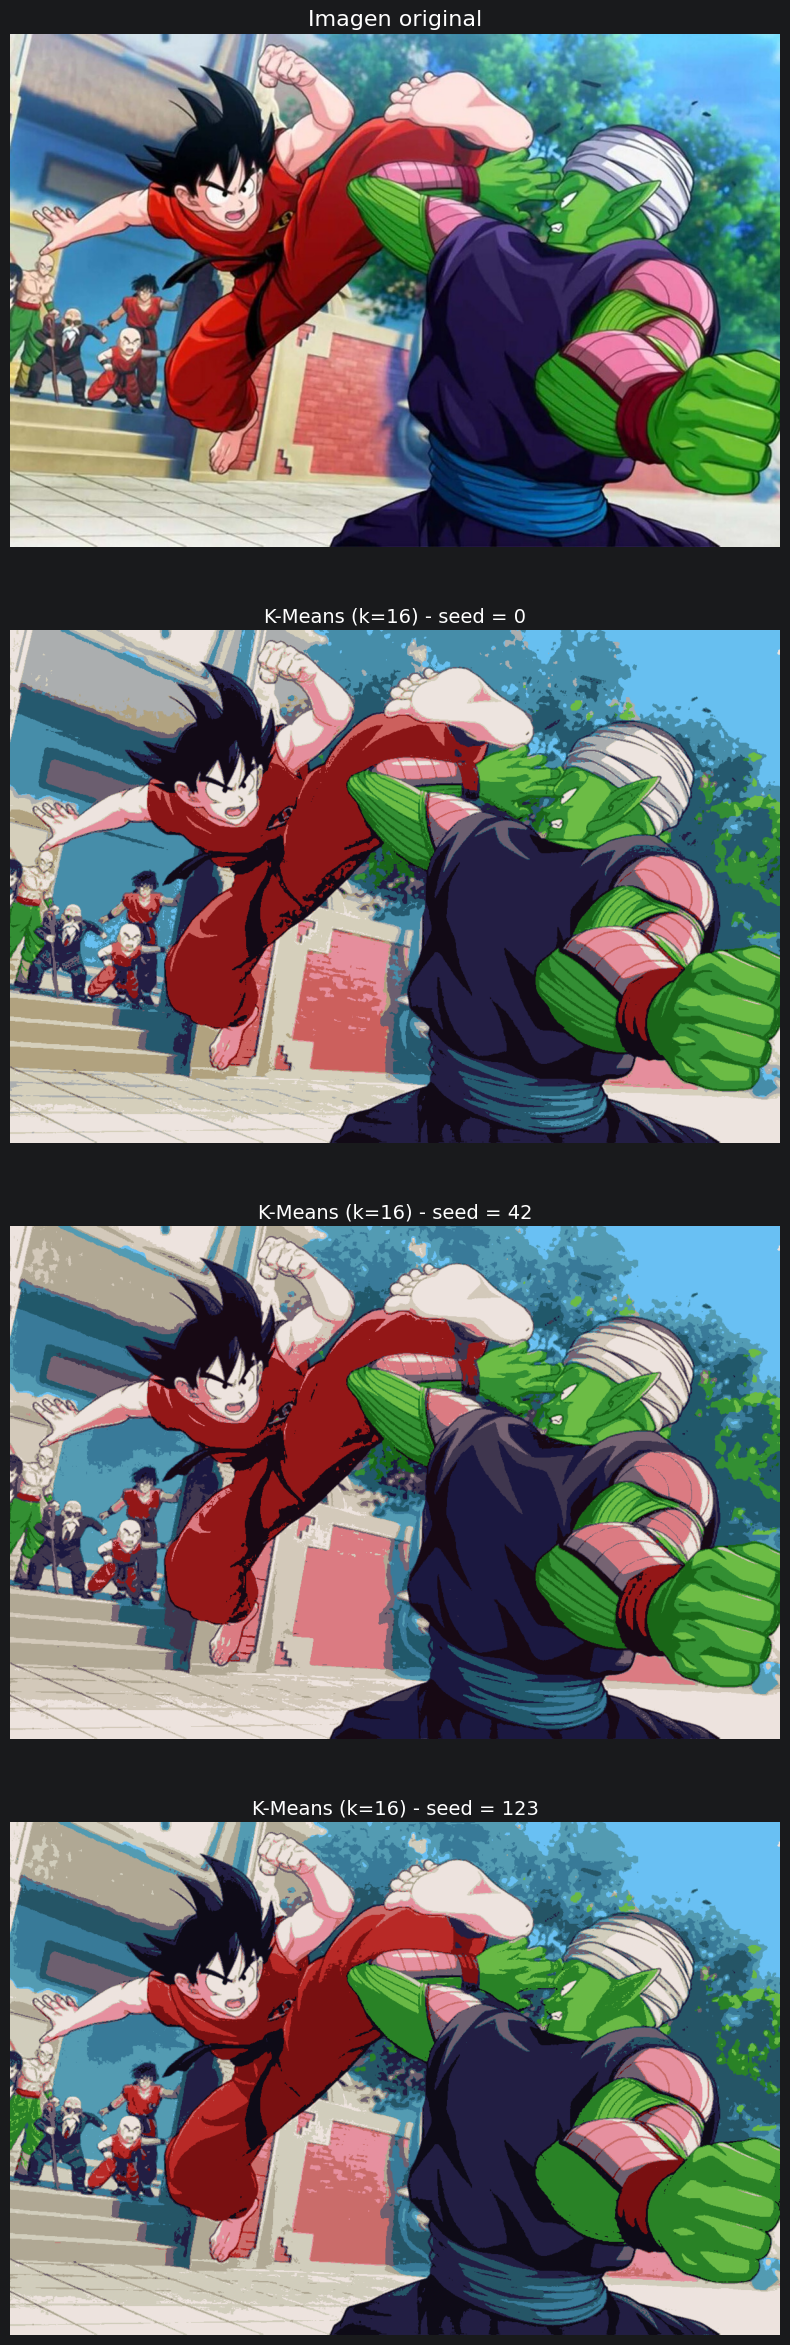

In [7]:
seeds = [0, 42, 123]

plt.figure(figsize=(8, 24))  # grande y vertical

# --- Imagen original ---
plt.subplot(4, 1, 1)
plt.imshow(img)
plt.title("Imagen original", fontsize=16)
plt.axis("off")

# --- KMeans con distintos seeds ---
for i, seed in enumerate(seeds):
    kmeans = KMeans(k=16, random_state=seed)
    kmeans.fit(X)

    labels = kmeans.predict(X)
    compressed = kmeans.cluster_centers_[labels]
    compressed_img = compressed.reshape(shape_original)

    # Asegurar tipo correcto
    if compressed_img.dtype != img.dtype:
        compressed_img = compressed_img.astype(img.dtype)

    plt.subplot(4, 1, i + 2)
    plt.imshow(compressed_img)
    plt.title(f"K-Means (k=16) - seed = {seed}", fontsize=14)
    plt.axis("off")

plt.tight_layout()
plt.show()

Se puede ver, comparando con la primer imagen que es la original, como se pierden principalmente los sombreados. Esto resulta esperable, ya que se baja la resolusion en color de $256^3 = 16777216$ a solamente $16$. Sin embargo, la escena de goku vs piccolo se puede seguir interpretando perfectamente, y si uno viera solamente una de las imagenes comprimidas sinconocer la original, es probable que ni note la compresión.

Lo que si resulta evidente entre las distintas imagenes comprimidas <y quizas lo que más corresponde en un informe del contexto de esta materia> es la influencia de los distintos centroides iniciales en la convergencia del algoritmo. Se puede ver como en algunas imagenes las sombras más oscuras se agruaron junto a los negros, mientras que en otras se agruparon junto al color principal. Si bien el criterio es difuso, y además probablemente varíe la influencia de imagen a imagen, se pueden probar distintos centroides semilla hasta obtener un resultado preferido.

Luego, para calcular el factor de compresion, se sabe que se parte de una imagen de dimensiones $alto \times ancho$, con $N = alto \cdot ancho$ píxeles.

Entonces se pueden calcular los bits que ocupa la imagen original:

$$
bits_{original} = N \cdot 3 \cdot 8 = N \cdot 24
$$

Luego, para los bits que ocupa la imagen comprimida, debemos tener en cuenta el espacio que ocupan las etiquetas y el espacio que ocupan los centroides


Las etiquetas dependerán de la cantidad k de centroides utilizados:

$$
bits_{labels} = N \cdot \lceil \log_2(k) \rceil
$$

Luego los centroides son colores en rgb, donde cada indice se guarda como entero de 8 bits:

$$
bits_{centroides} = k \cdot 3 \cdot 8 = k \cdot 24
$$

Por ultimo, el total de bits ocupados por la imagen comprimida resulta:

$$
bits_{comprimido} = N \cdot \lceil \log_2(k) \rceil + k \cdot 24
$$

In [8]:
N = alto * ancho
k = 16

# Cálculos
bits_original = N * 24
bits_labels = N * int(np.ceil(np.log2(k)))
bits_centroides = k * 24
bits_comprimido = bits_labels + bits_centroides

# Ratio y compresión porcentual
ratio = bits_original / bits_comprimido
reduccion = (1 - bits_comprimido / bits_original) * 100

print(f"N = {N}")
print(f"bits_original = {bits_original}")
print(f"bits_comprimido = {bits_comprimido}")
print(f"ratio = {ratio}")
print(f"reduccion (%) = {reduccion}")

N = 960000
bits_original = 23040000
bits_comprimido = 3840384
ratio = 5.9994000599940005
reduccion (%) = 83.33166666666668


Como se puede ver, el factor de compresión es muy alto, la imagen comprimida ocupa aproximadamente una sexta parte de la imagen original. Teniendo en cuenta esto, los resultados obtenidos son más que satisfactorios, se redujo considerablemente el tamaño de la imagen sin perder el concepto de esta con muy baja distorsión.

In [9]:
!mkdir -p data
!wget -q -O data/consumo_electrico.npy https://raw.githubusercontent.com/mvera1412/tallerPS/main/data/consumo_electrico.npy

A partir de ahora se trabajara con un dataset de consumo electrico:

In [10]:
data = np.load("data/consumo_electrico.npy")

print("Shape:", data.shape)
print(data)

Shape: (90, 24)
[[ 1.54967142e+00  1.75597034e+00  2.08435280e+00 ...  9.57838420e-01
   1.23695605e+00  1.35752518e+00]
 [ 1.44556173e+00  1.78088903e+00  1.90448459e+00 ...  9.08431629e-01
   1.18413935e+00  1.60571222e+00]
 [ 1.53436183e+00  1.59349276e+00  2.05199235e+00 ...  9.15904075e-01
   1.26634279e+00  1.65380366e+00]
 ...
 [-4.53248409e-02  1.82329466e-01  1.78255072e-01 ...  2.05899339e-01
  -1.73286876e-02 -1.62792906e-02]
 [ 4.09191754e-03 -6.31360329e-02  2.19663030e-01 ...  2.04762009e-01
   1.67864156e-03 -5.73601773e-02]
 [ 1.01856295e-02  1.91984728e-01  2.16698879e-02 ...  1.13809086e-01
   1.65247092e-01  5.57691061e-02]]


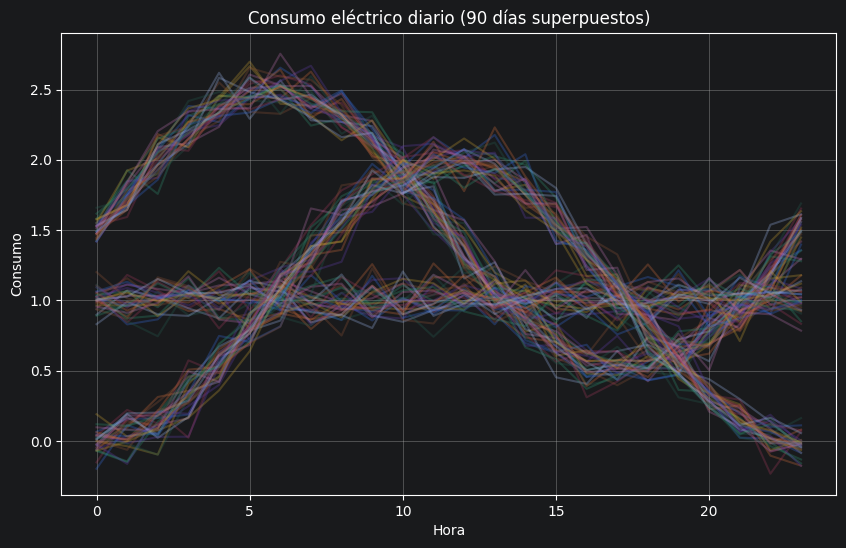

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for i in range(data.shape[0]):
    plt.plot(data[i], alpha=0.3)

plt.xlabel("Hora")
plt.ylabel("Consumo")
plt.title("Consumo eléctrico diario (90 días superpuestos)")

plt.grid()
plt.show()

Nuevamente se utilizara el algoritmo de k-means ya implementado con la intencion de separar las 3 tendencias claras en el consumo electrico.

In [12]:
# Cada fila ya es una muestra de 24 dimensiones
X = data

kmeans = KMeans(k=3, random_state=42)
labels = kmeans.fit_predict(X)

print("Centroides (perfiles típicos de consumo):")
print(kmeans.cluster_centers_)

Se llegó a la convergencia en 1 iteracioness
Centroides (perfiles típicos de consumo):
[[ 1.00984434e+00  9.91626705e-01  1.01122200e+00  1.04113412e+00
   1.00071799e+00  1.03136117e+00  1.03020510e+00  9.67746643e-01
   9.83676697e-01  1.00182745e+00  9.94913208e-01  1.00656791e+00
   1.03341742e+00  9.99011704e-01  1.00187527e+00  1.02633890e+00
   1.02659550e+00  9.93695602e-01  1.00457701e+00  1.02739915e+00
   1.01986326e+00  9.84181272e-01  1.02686276e+00  1.00083196e+00]
 [ 1.50843393e+00  1.75105280e+00  2.02043575e+00  2.22171233e+00
   2.38320600e+00  2.48031374e+00  2.50274794e+00  2.42919623e+00
   2.31687493e+00  2.15666850e+00  1.89767576e+00  1.65392300e+00
   1.36103124e+00  1.08287130e+00  8.53470862e-01  6.87807425e-01
   5.31205970e-01  5.48604122e-01  5.53317570e-01  6.13849017e-01
   7.55803879e-01  9.61134063e-01  1.20512744e+00  1.49929532e+00]
 [-1.23892993e-03  5.96897491e-02  1.22145197e-01  3.14511120e-01
   5.41576802e-01  7.98505144e-01  1.07193941e+00  1.

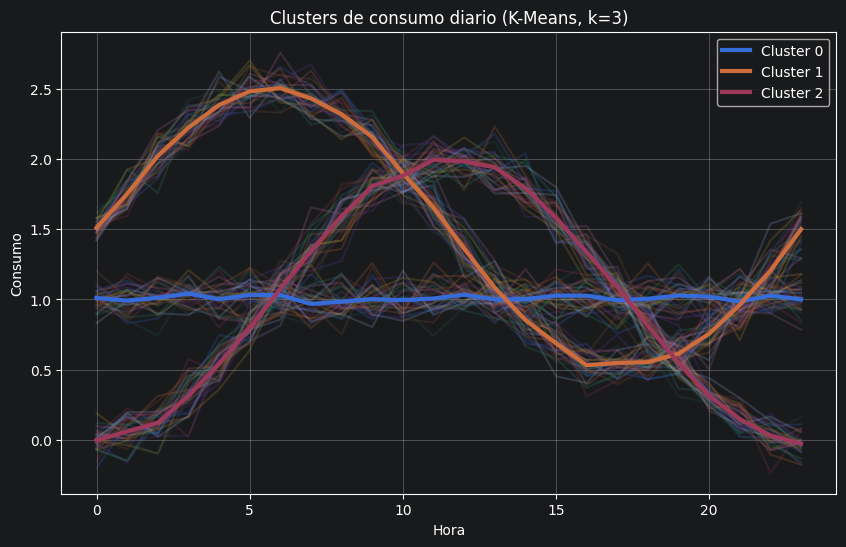

In [13]:
plt.figure(figsize=(10, 6))
for i in range(X.shape[0]):
    plt.plot(X[i], alpha=0.2)

for j in range(3):
    cluster_data = X[labels == j]
    plt.plot(kmeans.cluster_centers_[j], linewidth=3, label=f"Cluster {j}")

plt.xlabel("Hora")
plt.ylabel("Consumo")
plt.title("Clusters de consumo diario (K-Means, k=3)")
plt.legend()
plt.grid()
plt.show()

Si bien en las imágenes no se veía de forma explícita, en el caso anterior los centroides eran puntos en el espacio tridimensional de colores, ya que se agrupaban los colores cercanos geométricamente para encontrar un color "promedio" para una zona en el espacio.

En este caso, los centroides ya no se tratan de puntos, sino que pasan a ser curvas. Esto se debe a que ahora se agrupan curvas de consumo, entonces el promedio de estas es nuevamente una curva. Debido a que el consumo presenta una clara division en tres tendencias, el algoritmo funciona de la forma esperada, cada centroide se corresponde a una tendencia distinta en el consumo diario de electricidad.